In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
data=pd.read_csv(r"final_employee_dataset.csv")

In [26]:
data.columns[1:6]

Index(['satisfactory_Level', 'last_Evaluation', 'number_Of_Projects',
       'avg_Monthly_Hours', 'time_Spent_Company'],
      dtype='object')

**1️⃣Univariate Analysis (Understand Each Feature)**


Goal: Understand distribution of each column individually.

Steps
Numerical columns

satisfactoryLevel

lastEvaluation

avgMonthlyHours

numberOfProjects

timeSpent.company

Code

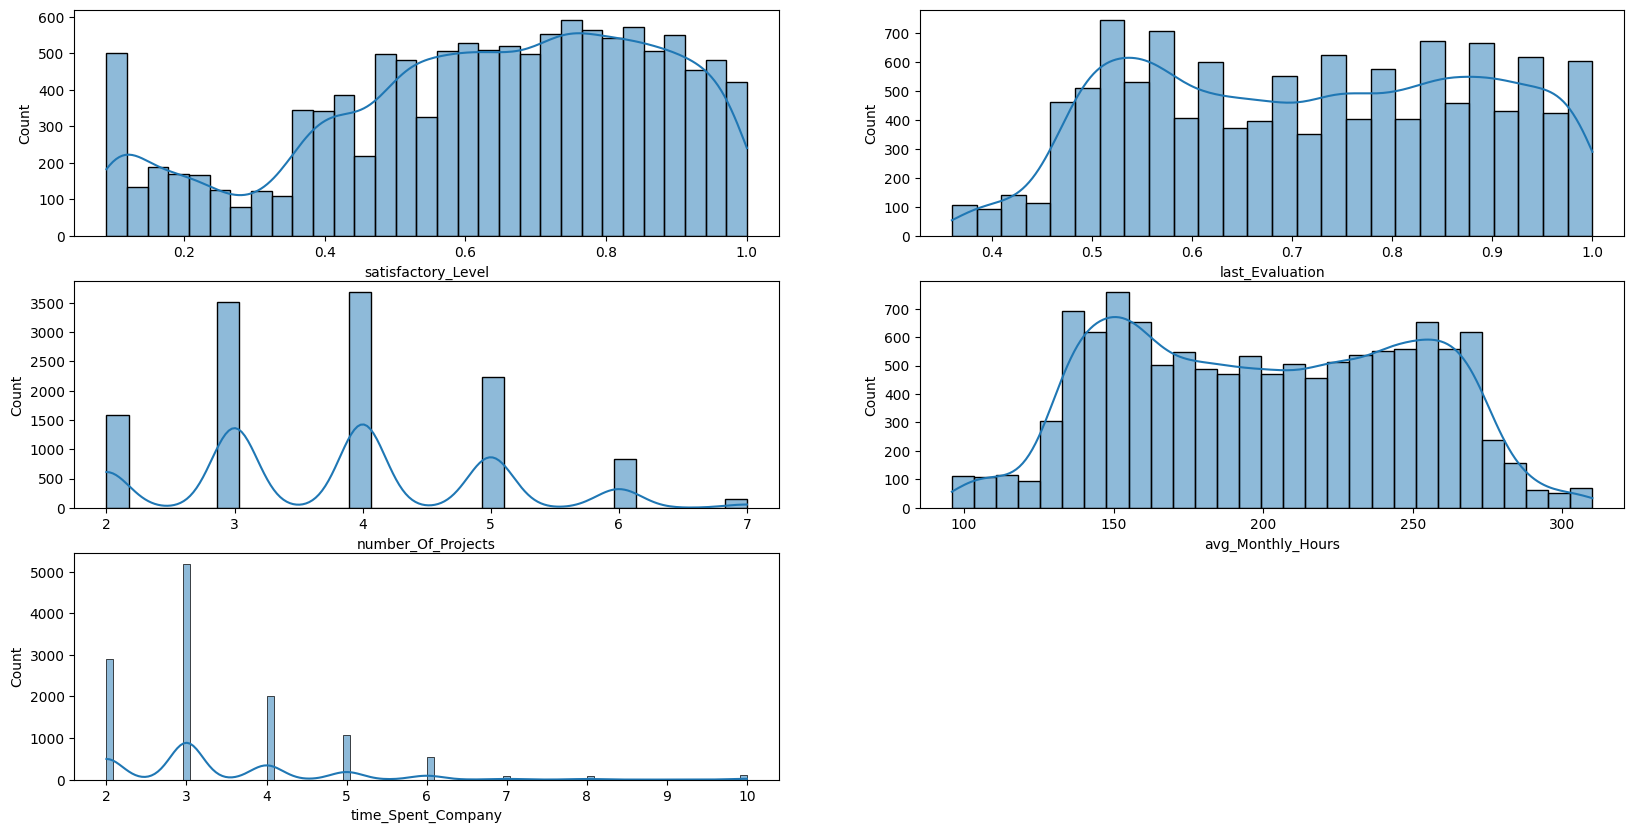

In [27]:
j=1
plt.figure(figsize=(20,10))
for i in data.columns[1:6]:
    plt.subplot(3,2,j)
    j+=1
    sns.histplot(data[i], kde=True)
    plt.xlabel(i)
plt.show()

# Insights 

satisfactory_level: Most employees have satisfaction levels between 0.5 and 0.9, indicating generally moderate to high job satisfaction.

last_evaluation: Employee performance evaluations are mostly concentrated between 0.5 and 0.9, showing that most employees receive average to high performance scores.

number_of_projects: Most employees work on 3 to 5 projects, with very few employees handling extremely high numbers of projects.

avg_monthly_hours: The majority of employees work between 150 and 270 hours per month, suggesting a relatively high workload.

time_spent_company: Most employees have stayed in the company for 2 to 4 years, with fewer employees remaining for very long periods.

# **2️⃣ Target Variable Analysis**

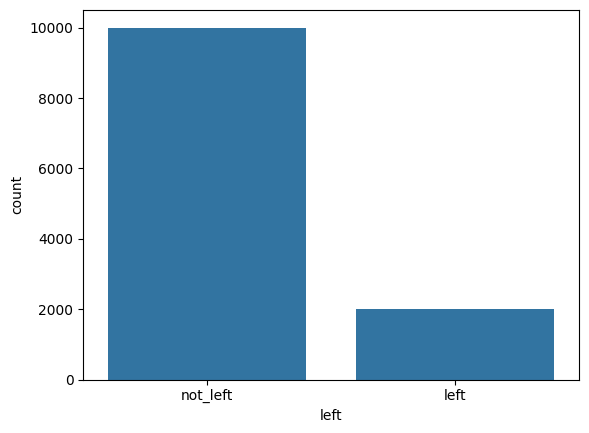

In [28]:
sns.countplot(x="left", data=data)

plt.xticks([0,1], ["not_left", "left"])

plt.show()

In [29]:
total_employees=data["left"].count()
left_employees=data["left"].value_counts()[1]
left_ratio=(left_employees/total_employees)*100
print(int(left_ratio))

16


**insights** : 
16% employees left the company

# 3️⃣ Categorical Feature Analysis

<Axes: xlabel='salary', ylabel='count'>

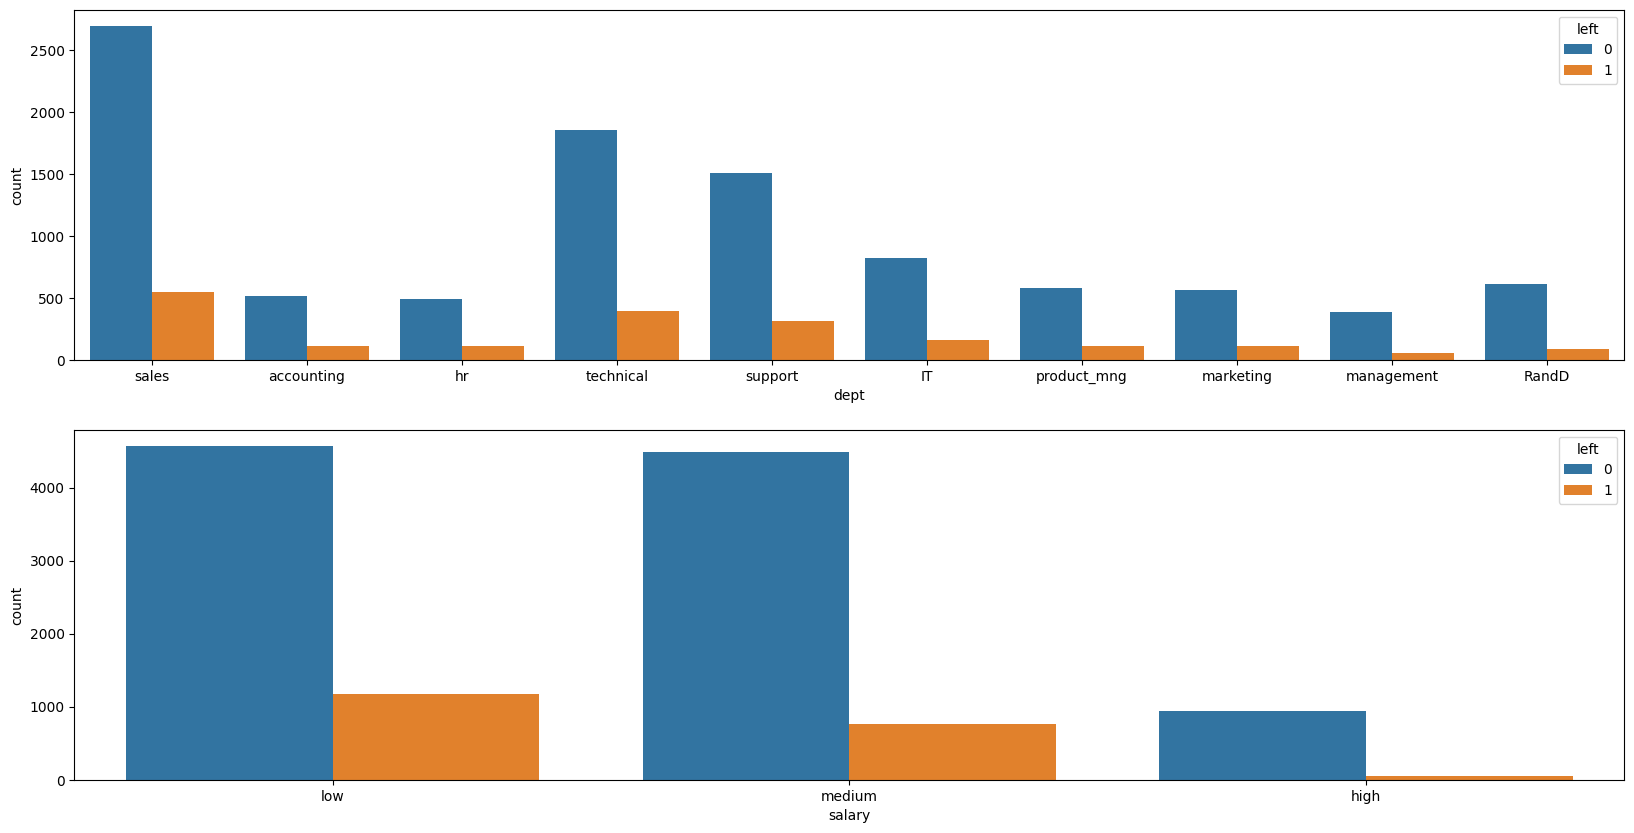

In [35]:
plt.figure(figsize=(20,10))
plt.subplot(2,1,1)
sns.countplot(x="dept",data=data,hue="left")
plt.subplot(2,1,2)
sns.countplot(x="salary",data=data,hue="left")

In [38]:
# ratio of employee left from each department
data.groupby("dept")["left"].sum() / data.groupby("dept")["left"].count()

dept
IT             0.161885
RandD          0.122478
accounting     0.175523
hr             0.188020
management     0.119266
marketing      0.166419
product_mng    0.160350
sales          0.169805
support        0.171334
technical      0.173797
Name: left, dtype: float64

**insights** : almost same number of employees left from each department

In [39]:
#ratio of employees who left based on salary level.
data.groupby("salary")["left"].mean()

salary
high      0.048485
low       0.204530
medium    0.146170
Name: left, dtype: float64

**insights** most of the employee with low salary left the comapny , then medium level salary employees left

# 4️⃣ Feature vs Target Analysis

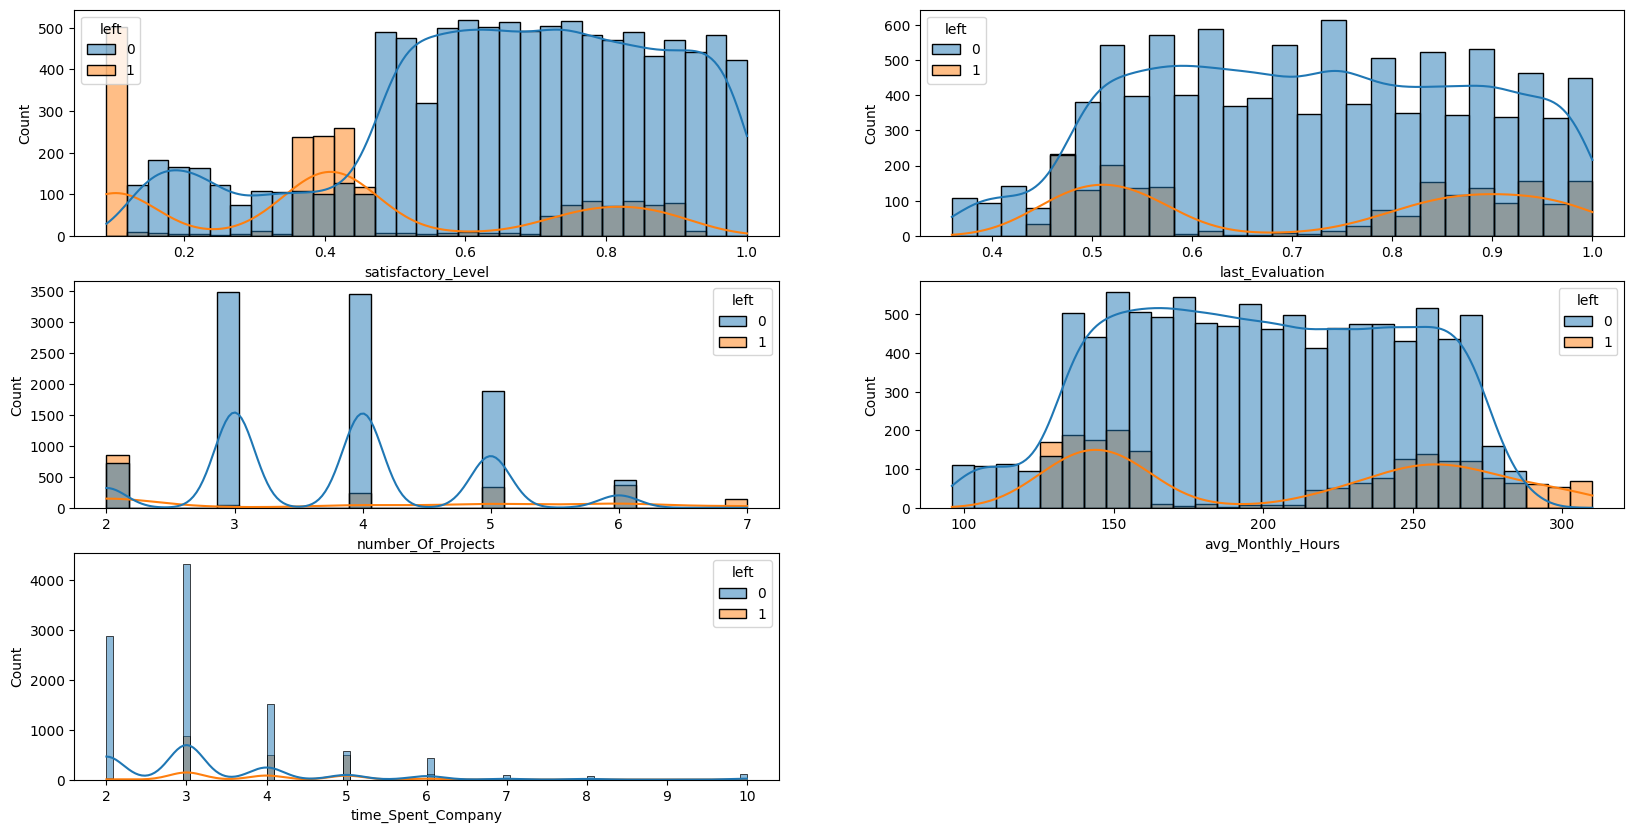

In [48]:
j=1
plt.figure(figsize=(20,10))
for i in data.columns[1:6]:
    plt.subplot(3,2,j)
    j+=1
    sns.histplot(x=i,data=data,hue="left",kde=True)
    plt.xlabel(i)
plt.show()

### Insights from Numerical Features vs Employee Turnover

- **Satisfaction Level vs Leaving:** Employees with very low satisfaction levels are significantly more likely to leave the company compared to employees with higher satisfaction.

- **Last Evaluation vs Leaving:** Employees who left tend to have either relatively low or very high performance evaluations, suggesting both underperformance and overwork may contribute to attrition.

- **Number of Projects vs Leaving:** Employees handling a very high number of projects (around 6–7) show higher turnover, indicating possible workload stress.

- **Average Monthly Hours vs Leaving:** Employees who work very high monthly hours tend to leave more frequently, suggesting that excessive workload may lead to burnout.

- **Time Spent in Company vs Leaving:** Employees with around 3–5 years of tenure show higher attrition, indicating that mid-tenure employees may leave for better career opportunities.

### correlation analysis

<Axes: >

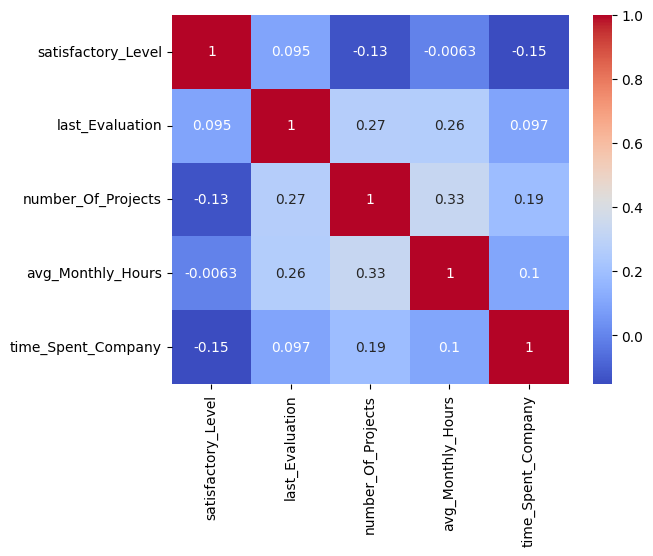

In [55]:
corr=data.iloc[:,1:6].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")

### Insights from Correlation Analysis

- **Projects vs Monthly Hours:** There is a moderate positive correlation (0.33) between number of projects and average monthly hours, indicating that employees assigned more projects tend to work longer hours.

- **Evaluation vs Projects:** Last evaluation shows a positive correlation (0.27) with number of projects, suggesting employees with higher performance evaluations are often assigned more projects.

- **Evaluation vs Working Hours:** Last evaluation is also positively correlated (0.26) with monthly working hours, implying that employees who work more hours tend to receive higher performance evaluations.

- **Satisfaction vs Time in Company:** Satisfaction level has a slight negative correlation (-0.15) with time spent in the company, indicating that employee satisfaction may decrease slightly as tenure increases.

- **Satisfaction vs Projects:** Satisfaction level has a weak negative correlation (-0.13) with number of projects, suggesting that employees handling more projects might experience slightly lower satisfaction.

- **Overall Observation:** Most correlations are relatively weak, meaning employee attributes are not strongly linearly dependent on each other and may influence employee turnover in combination rather than individually.

# 8️⃣ Grouped Business Analysis

In [64]:
for i in data.select_dtypes(exclude="object").columns[1:]:

    display(data.groupby("left")[i].mean())
    print()

left
0    0.667365
1    0.440271
Name: satisfactory_Level, dtype: float64

left
0    0.715667
1    0.721783
Name: last_Evaluation, dtype: float64

left
0    3.786800
1    3.883476
Name: number_Of_Projects, dtype: float64

left
0    198.94270
1    208.16223
Name: avg_Monthly_Hours, dtype: float64

left
0    3.262000
1    3.881467
Name: time_Spent_Company, dtype: float64

left
0    0.174500
1    0.052737
Name: work_Accident, dtype: float64

left
0    0.0
1    1.0
Name: left, dtype: float64

left
0    0.019500
1    0.004018
Name: promotion_In_Last5years, dtype: float64